<div style="
background-color:#f0f7ff;
border:2px solid #4a90e2;
border-radius:12px;
padding:15px;
">

### Emergency Room Wait Time Project

</div>


<div style="
background: #f0f7ff;
border-left:2px solid #4a90e2;
border-radius:12px;
padding:12px;
font-size:15px;
">

### The problem
- In emergency rooms, time is critical. Long waiting times can increase patient stress, reduce satisfaction, and in some cases, negatively affect health outcomes.
- However, patient wait time is not random. It is influenced by multiple factors such as patient age, department referral, admission status, hospital workload, and other operational conditions.
- Hospitals often struggle to anticipate peak congestion periods or identify which factors contribute most to long delays. Without predictive insights, managing resources efficiently becomes challenging, leading to overcrowding and reduced quality of service.

### The solution
In this project, we develop a regression model to predict patient wait time in the emergency room using historical hospital data.

The dataset includes patient demographics, admission details, referral departments, and satisfaction scores. By analyzing these variables, we aim to:
- Identify **key factors** that drive **longer waiting times**.
- Provide **insights** that support **better hospital resource planning**.
- **Predict expected wait time** for incoming patients

Our goal is not only to build an accurate predictive model, but also to generate actionable insights that can help hospitals:
- Improve resource allocation
- Reduce overcrowding
- Enhance patient satisfaction
- Make data-driven operational decisions

This project demonstrates how machine learning can be applied to real-world healthcare challenges, transforming raw hospital records into meaningful predictions that improve both operational efficiency and patient experience.

</div>

<div style="
background-color:#f0f7ff;
border:2px solid #4a90e2;
border-radius:12px;
padding:15px;
">

| Feature                            | Description                                                          |
| ---------------------------------- | -------------------------------------------------------------------- |
| Visit ID                           | Unique identifier for each hospital visit.                           |
| Patient ID                         | Unique identifier assigned to each patient.                          |
| Hospital ID                        | Unique identifier for the hospital where the visit occurred.         |
| Hospital Name                      | Name of the hospital where the patient was treated.                  |
| Region                             | Geographic region where the hospital is located.                     |
| Visit Date                         | Date when the patient visited the hospital.                          |
| Day of Week                        | Day of the week when the visit occurred.                             |
| Season                             | Season of the year during which the visit happened.                  |
| Time of Day                        | Time period of the visit (e.g., morning, afternoon, evening, night). |
| Urgency Level                      | Level of medical urgency assigned to the patient at arrival.         |
| Nurse-to-Patient Ratio             | Ratio of available nurses to patients at the time of the visit.      |
| Specialist Availability            | Indicates whether a medical specialist was available.                |
| Facility Size (Beds)               | Total number of beds available in the hospital facility.             |
| Time to Registration (min)         | Time taken from arrival until the patient completes registration.    |
| Time to Triage (min)               | Time taken before the patient is assessed and triaged.               |
| Time to Medical Professional (min) | Time taken before the patient sees a doctor or medical professional. |
| Total Wait Time (min)              | Total waiting time from arrival until receiving medical attention.   |
| Patient Outcome                    | Final result of the visit (e.g., admitted, discharged).              |
| Patient Satisfaction               | Patient’s satisfaction level or score after the visit.               |

</div>

<div style="
background-color:#f0f7ff;
border:2px solid #4a90e2;
border-radius:12px;
padding:15px;
">

### Project Steps:
**Goal:** Predict patient wait time using regression models.

**Steps**
- Import Libraries
- Read Data
- Exploratory Data Analysis
- Data Cleaning
- Model training
- Evaluation

</div>


## Import Libraries

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
 
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from pathlib import Path
import joblib
import shutil

In [2]:
import numpy as np


def mape_percent_eps(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.maximum(np.abs(y_true), eps)
    return np.mean(np.abs((y_true - y_pred) / denom)) * 100


def eval_regression(y_true, y_pred):
    return {
        "R2": r2_score(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAPE_%": mape_percent_eps(y_true, y_pred),
    }


## Read Data

In [3]:
REPO_ROOT = Path.cwd().parent
DATA_DIR = REPO_ROOT / "data"
DATA_DIR.mkdir(parents=True, exist_ok=True)

os.environ["KAGGLEHUB_CACHE"] = str(DATA_DIR.resolve())

download_path = Path(kagglehub.dataset_download("rivalytics/er-wait-time"))

for item in download_path.iterdir():
    target = DATA_DIR / item.name
    if item.is_file():
        shutil.copy2(item, target)
    elif item.is_dir():
        shutil.copytree(item, target, dirs_exist_ok=True)

print("Files copied to:", DATA_DIR.resolve())

Files copied to: /mnt/c/Users/osama/Downloads/MLProject/data


In [4]:
BASE_DIR = Path().resolve().parent
CSV_PATH = BASE_DIR / "data" / "ER Wait Time Dataset.csv"

In [5]:
df = pd.read_csv(CSV_PATH)

# shows the number of rows and columns of the df
print(df.shape)

(5000, 19)


In [6]:
df.columns

Index(['Visit ID', 'Patient ID', 'Hospital ID', 'Hospital Name', 'Region',
       'Visit Date', 'Day of Week', 'Season', 'Time of Day', 'Urgency Level',
       'Nurse-to-Patient Ratio', 'Specialist Availability',
       'Facility Size (Beds)', 'Time to Registration (min)',
       'Time to Triage (min)', 'Time to Medical Professional (min)',
       'Total Wait Time (min)', 'Patient Outcome', 'Patient Satisfaction'],
      dtype='object')

## Split Data int Train and Test

In [7]:
# Temporal split — sort by Visit Date to avoid future leakage
df["Visit Date"] = pd.to_datetime(df["Visit Date"])
df = df.sort_values("Visit Date").reset_index(drop=True)

split_idx = int(len(df) * 0.8)
train_data = df.iloc[:split_idx].copy()
test_data  = df.iloc[split_idx:].copy()

In [8]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 19 columns):
 #   Column                              Non-Null Count  Dtype         
---  ------                              --------------  -----         
 0   Visit ID                            4000 non-null   object        
 1   Patient ID                          4000 non-null   object        
 2   Hospital ID                         4000 non-null   object        
 3   Hospital Name                       4000 non-null   object        
 4   Region                              4000 non-null   object        
 5   Visit Date                          4000 non-null   datetime64[ns]
 6   Day of Week                         4000 non-null   object        
 7   Season                              4000 non-null   object        
 8   Time of Day                         4000 non-null   object        
 9   Urgency Level                       4000 non-null   object        
 10  Nurse-to-Patient Ratio  

## EDA - Exploratory Data Analysis

In [9]:
train_data[['Visit ID', 'Patient ID', 'Hospital ID']].head()

,Visit ID,Patient ID,Hospital ID
0,HOSP-3-20240101-0331,PAT-01629,HOSP-3
1,HOSP-1-20240101-0492,PAT-02404,HOSP-1
2,HOSP-1-20240101-0487,PAT-02360,HOSP-1
3,HOSP-5-20240101-0663,PAT-03480,HOSP-5
4,HOSP-3-20240101-0625,PAT-03117,HOSP-3


In [10]:
train_data[['Visit ID', 'Patient ID', 'Hospital ID']].tail()

,Visit ID,Patient ID,Hospital ID
3995,HOSP-3-20241017-0805,PAT-04084,HOSP-3
3996,HOSP-1-20241018-0456,PAT-02240,HOSP-1
3997,HOSP-2-20241018-0133,PAT-00710,HOSP-2
3998,HOSP-2-20241018-0448,PAT-02208,HOSP-2
3999,HOSP-3-20241018-0816,PAT-04140,HOSP-3


**Note**
- These are just **identifier**, So we can **drop** them.

In [11]:
train_data['Hospital Name'].value_counts()

Hospital Name
Riverside Medical Center        825
St. Mary’s Regional Health      812
Northside Community Hospital    804
Summit Health Center            785
Springfield General Hospital    774
Name: count, dtype: int64

**Note**
- Using OneHotEncoder for this column because it's a **nominal column**.

In [12]:
train_data['Region'].value_counts()

Region
Urban    2384
Rural    1616
Name: count, dtype: int64

**Note**
- It's a **categorical** column that contains only 2 values:
  - Urban
  - Rural

- We will apply **OneHotEncoder** on it.

In [13]:
train_data['Visit Date'].head()

0   2024-01-01 05:08:49
1   2024-01-01 08:52:28
2   2024-01-01 09:13:59
3   2024-01-01 14:42:17
4   2024-01-01 17:08:15
Name: Visit Date, dtype: datetime64[ns]

In [14]:
train_data['Day of Week'].value_counts()

Day of Week
Monday       601
Tuesday      595
Thursday     593
Sunday       570
Saturday     568
Friday       548
Wednesday    525
Name: count, dtype: int64

**Note**
- It's a **categorical** column.
- We will apply **OneHotEncoder** on it.

In [15]:
train_data['Season'].value_counts()

Season
Summer    1281
Spring    1227
Winter     854
Fall       638
Name: count, dtype: int64

**Note**
- It's a **categorical** column.
- We will apply **OneHotEncoder** on it.

In [16]:
train_data['Time of Day'].value_counts()

Time of Day
Evening          1374
Afternoon        1200
Late Morning      621
Night             428
Early Morning     377
Name: count, dtype: int64

**Note**
- It's a **categorical** column.
- We will apply **OneHotEncoder** on it.

In [17]:
train_data['Urgency Level'].value_counts()

Urgency Level
Medium      1017
Critical    1008
High         989
Low          986
Name: count, dtype: int64

**Note**
- It's a **categorical** column.
- We will apply **OneHotEncoder** on it.

In [18]:
train_data['Nurse-to-Patient Ratio'].head()

0    3
1    2
2    3
3    4
4    3
Name: Nurse-to-Patient Ratio, dtype: int64

In [19]:
train_data['Nurse-to-Patient Ratio'].dtype

dtype('int64')

In [20]:
train_data['Specialist Availability'].value_counts()

Specialist Availability
1     675
3     657
2     650
0     376
4     263
10    255
6     237
5     230
9     228
8     227
7     202
Name: count, dtype: int64

In [21]:
train_data['Specialist Availability'].dtype

dtype('int64')

In [22]:
train_data['Facility Size (Beds)'].head()

0     10
1     67
2    151
3    155
4     18
Name: Facility Size (Beds), dtype: int64

- It's a **numerical** column, it will requires **scaling**.

In [23]:
train_data['Time to Triage (min)'].head()

0     27
1      6
2     31
3    135
4     15
Name: Time to Triage (min), dtype: int64

In [24]:
train_data['Time to Registration (min)'].head()

0    17
1     1
2    24
3    64
4     8
Name: Time to Registration (min), dtype: int64

In [25]:
train_data['Time to Medical Professional (min)'].head()

0     76
1     15
2     46
3    145
4     44
Name: Time to Medical Professional (min), dtype: int64

In [26]:
train_data['Patient Outcome'].value_counts()

Patient Outcome
Discharged                 2301
Admitted                   1491
Left Without Being Seen     208
Name: count, dtype: int64

In [27]:
train_data['Patient Satisfaction'].value_counts()

Patient Satisfaction
1    1243
4    1138
3     687
2     479
5     453
Name: count, dtype: int64

**Note**
- It's a **Post-visit** column.
- We will **drop** it.

In [28]:
train_data.isnull().sum()

Visit ID                              0
Patient ID                            0
Hospital ID                           0
Hospital Name                         0
Region                                0
Visit Date                            0
Day of Week                           0
Season                                0
Time of Day                           0
Urgency Level                         0
Nurse-to-Patient Ratio                0
Specialist Availability               0
Facility Size (Beds)                  0
Time to Registration (min)            0
Time to Triage (min)                  0
Time to Medical Professional (min)    0
Total Wait Time (min)                 0
Patient Outcome                       0
Patient Satisfaction                  0
dtype: int64

**Note**
- There is **no missing values** in the dataset.

In [29]:
train_data.describe()

,Visit Date,Nurse-to-Patient Ratio,Specialist Availability,Facility Size (Beds),Time to Registration (min),Time to Triage (min),Time to Medical Professional (min),Total Wait Time (min),Patient Satisfaction
count,4000,4000.000000,4000.000000,4000.00000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,2024-05-24 21:17:41.149500160,3.231250,3.850500,86.59800,11.723000,24.973500,45.430250,82.126750,2.769750
min,2024-01-01 05:08:49,1.000000,0.000000,10.00000,0.000000,1.000000,2.000000,4.000000,1.000000
25%,2024-03-11 19:19:47.249999872,2.000000,1.000000,36.00000,3.000000,6.000000,17.000000,27.000000,1.000000
50%,2024-05-26 04:50:03.500000,3.000000,3.000000,72.50000,8.000000,16.000000,34.500000,60.000000,3.000000
75%,2024-08-05 18:12:43,4.000000,6.000000,137.00000,18.000000,36.000000,67.000000,123.000000,4.000000
max,2024-10-18 09:12:00,5.000000,10.000000,200.00000,66.000000,163.000000,233.000000,442.000000,5.000000
std,NaN,1.205669,3.032152,57.93347,10.451559,24.899634,35.528886,68.077653,1.430995


## Visualization

#### Show the Distribution of Total Wait Time

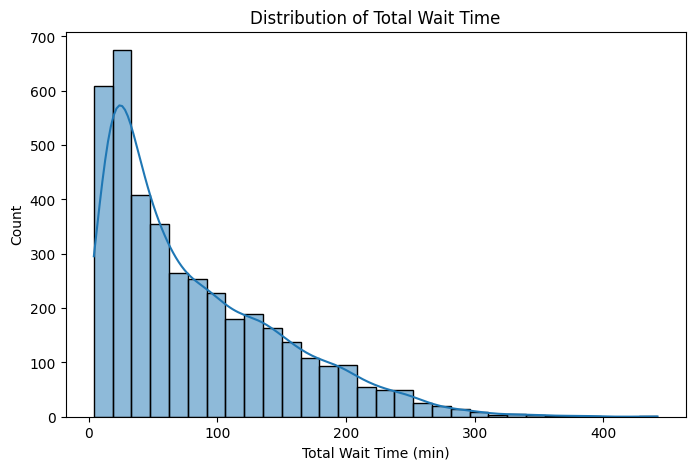

In [30]:
y = train_data['Total Wait Time (min)']
plt.figure(figsize=(8,5))
sns.histplot(y, bins=30, kde=True)
plt.title("Distribution of Total Wait Time")
plt.show()

- There is **right skewness** in the target variable (total wait time).

#### Urgency Level V.S. Total Wait Time

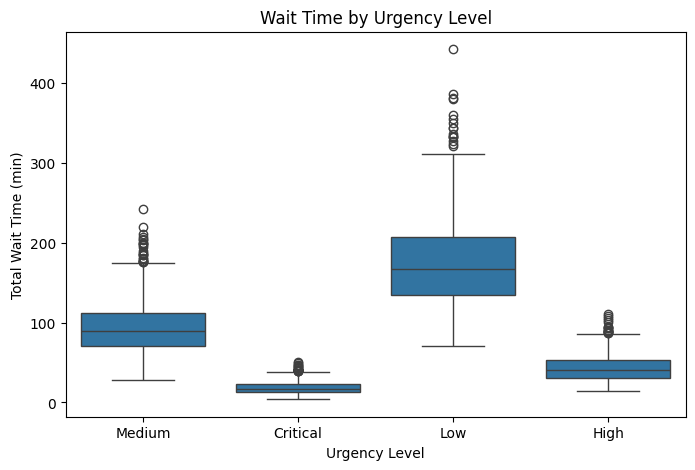

In [31]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="Urgency Level", y="Total Wait Time (min)", data=train_data)
plt.title("Wait Time by Urgency Level")
plt.show()

- When the emergency level is **critical**, It takes the **lowest wait time**.
- **Low emergency** takes the **highest wait time**.
- From this graph, We can conclude that as the **emergency level is grow**, the **wait time decreases**.

#### Time of Day V.S. Wait time  


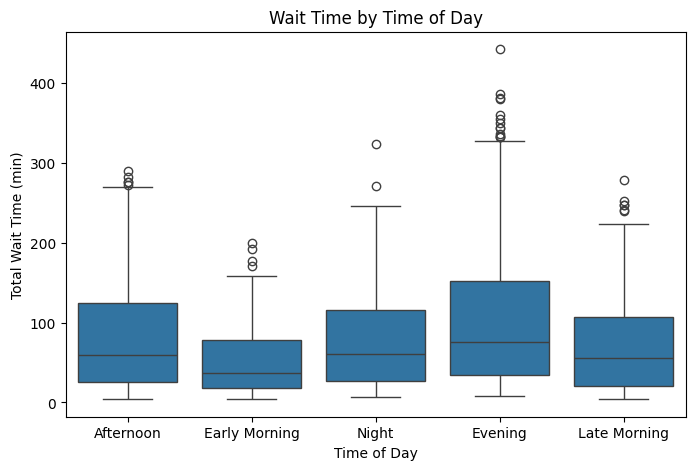

In [32]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="Time of Day", y="Total Wait Time (min)", data=train_data)
plt.title("Wait Time by Time of Day")
plt.show()

- **Evening** takes the **most wait time**.

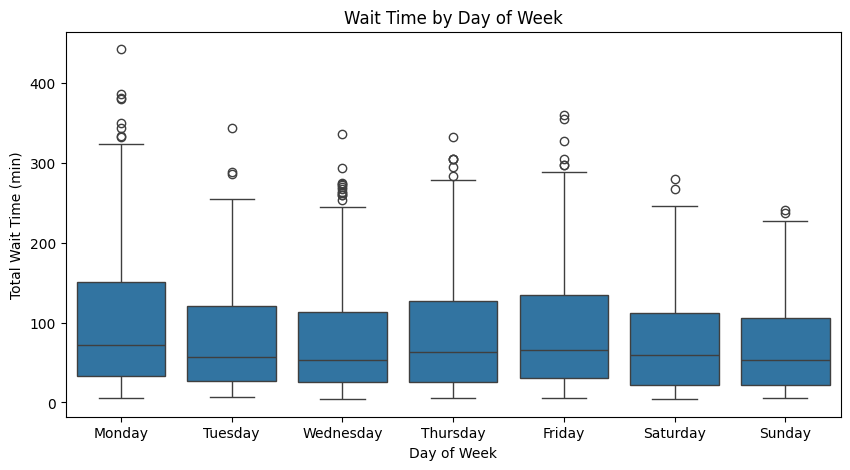

In [33]:
plt.figure(figsize=(10, 5))
sns.boxplot(x="Day of Week", y="Total Wait Time (min)", data=train_data)
plt.title("Wait Time by Day of Week")
plt.show()

- **Total wait time** spikes in **Monday.**

#### Season V.S. Wait Time

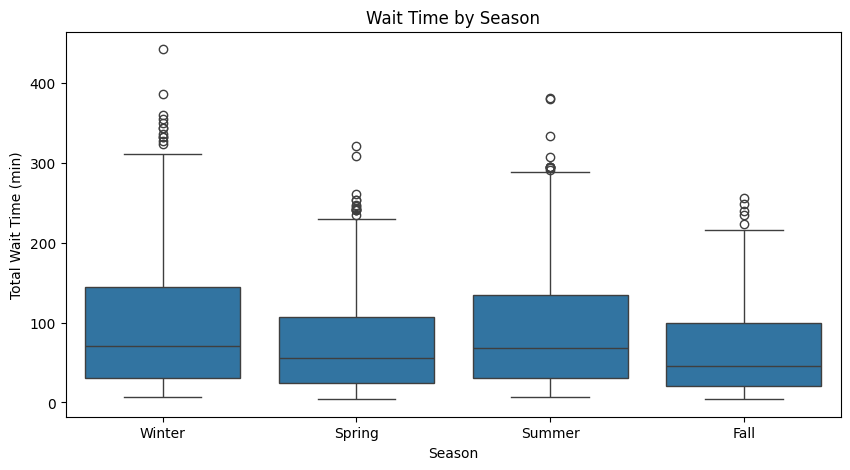

In [34]:
plt.figure(figsize=(10,5))
sns.boxplot(x="Season", y="Total Wait Time (min)", data=train_data)
plt.title("Wait Time by Season")
plt.show()

- **Winter** takes the **longest total wait time**.

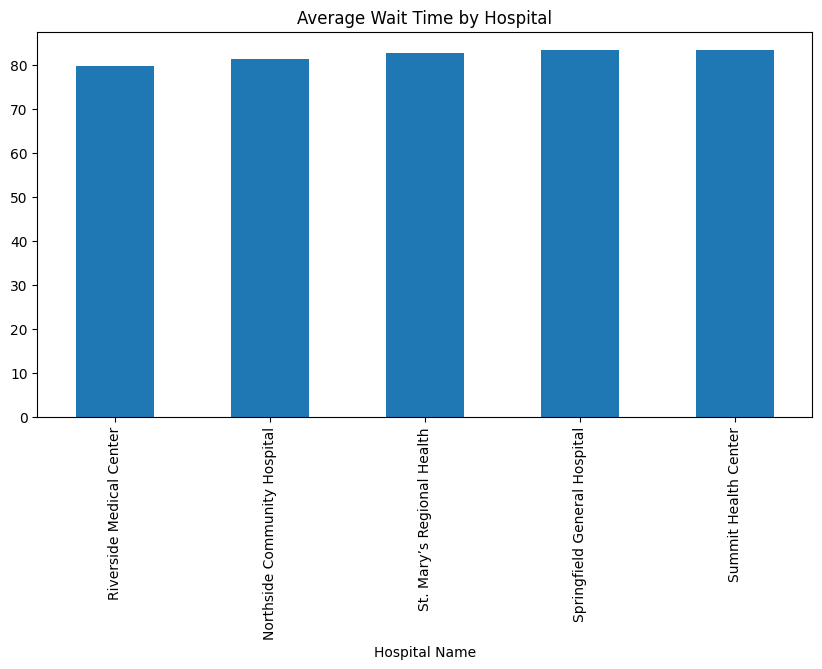

In [35]:
avg_wait = train_data.groupby("Hospital Name")["Total Wait Time (min)"].mean().sort_values()

avg_wait.plot(kind="bar", figsize=(10,5))
plt.title("Average Wait Time by Hospital")
plt.show()

- **Total wait time** for hospitals is really **close to each other**.

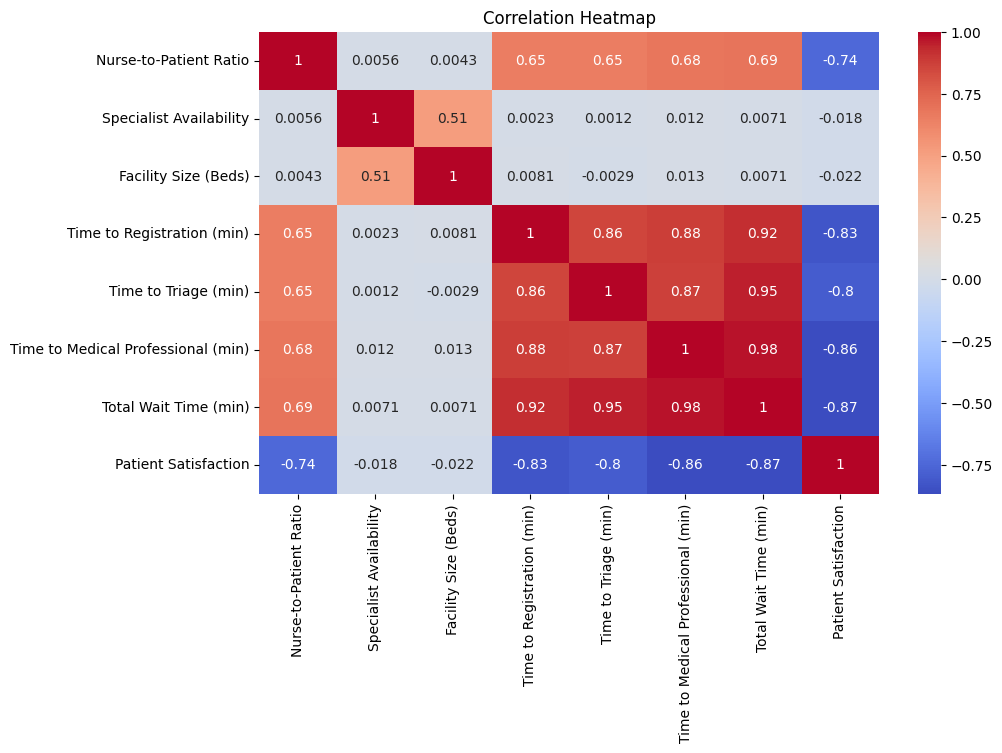

In [36]:
plt.figure(figsize=(10,6))
sns.heatmap(train_data.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## Data Cleaning

In [37]:
target = "Total Wait Time (min)"

y = train_data[target]
X = train_data.drop(columns=[target])

In [38]:
X.sample()

,Visit ID,Patient ID,Hospital ID,Hospital Name,Region,Visit Date,Day of Week,Season,Time of Day,Urgency Level,Nurse-to-Patient Ratio,Specialist Availability,Facility Size (Beds),Time to Registration (min),Time to Triage (min),Time to Medical Professional (min),Patient Outcome,Patient Satisfaction
1096,HOSP-4-20240319-0084,PAT-00484,HOSP-4,St. Mary’s Regional Health,Rural,2024-03-19 07:45:03,Tuesday,Spring,Evening,Critical,1,0,33,3,3,11,Discharged,5


In [39]:
X["Visit Date"] = pd.to_datetime(train_data["Visit Date"])

X["hour"] = X["Visit Date"].dt.hour
X["day"] = X["Visit Date"].dt.day
X["month"] = X["Visit Date"].dt.month
X["day_of_week"] = X["Visit Date"].dt.dayofweek

In [40]:
X.drop(columns=["Visit Date"], inplace=True)

In [41]:
X.dtypes

Visit ID                              object
Patient ID                            object
Hospital ID                           object
Hospital Name                         object
Region                                object
Day of Week                           object
Season                                object
Time of Day                           object
Urgency Level                         object
Nurse-to-Patient Ratio                 int64
Specialist Availability                int64
Facility Size (Beds)                   int64
Time to Registration (min)             int64
Time to Triage (min)                   int64
Time to Medical Professional (min)     int64
Patient Outcome                       object
Patient Satisfaction                   int64
hour                                   int32
day                                    int32
month                                  int32
day_of_week                            int32
dtype: object

- Drop unnessecary columns:
  - Visit ID
  - Patient ID
  - Hospital ID
  - Patient Satisfaction Post-visit
  - Patient Outcome Post-visit

In [42]:
X.drop(columns=['Visit ID', 'Patient ID', 'Hospital ID', 'Patient Satisfaction', 'Patient Outcome'], inplace=True)
X.sample()

,Hospital Name,Region,Day of Week,Season,Time of Day,Urgency Level,Nurse-to-Patient Ratio,Specialist Availability,Facility Size (Beds),Time to Registration (min),Time to Triage (min),Time to Medical Professional (min),hour,day,month,day_of_week
3091,Springfield General Hospital,Urban,Monday,Summer,Late Morning,Low,4,6,51,20,53,91,16,12,8,0


In [43]:
categorical_cols = X.select_dtypes(include=["object"]).columns
numerical_cols = X.select_dtypes(exclude=["object"]).columns

- Preprocessing for Numerical and Categerical Columns:
  - StandardScaler for numerical columns
  - OneHotEncoder for categorical columns

In [44]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

## Split Data into Train and Validation

In [45]:
results = []

def add_result(model_name, y_true, y_pred):
    m = eval_regression(y_true, y_pred)
    results.append({"Model": model_name, **m})


In [46]:
# Temporal train/val split (X is already sorted via df sort above)
split_idx = int(len(X) * 0.8)
X_train_h = X.iloc[:split_idx].copy()
X_holdout = X.iloc[split_idx:].copy()
y_train_h = y.iloc[:split_idx].copy()
y_holdout = y.iloc[split_idx:].copy()

## BaseLine Model (DummyRegressor)

In [47]:
baseline_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", DummyRegressor(strategy="mean"))
])

baseline_model.fit(X_train_h, y_train_h)

y_pred_base = baseline_model.predict(X_holdout)

add_result("DummyRegressor", y_holdout, y_pred_base)
metrics = eval_regression(y_holdout, y_pred_base)
print(f"R2:      {metrics['R2']:.4f}")
print(f"MAE:     {metrics['MAE']:.4f}")
print(f"RMSE:    {metrics['RMSE']:.4f}")
print(f"MAPE_%:  {metrics['MAPE_%']:.2f}")

R2:      -0.0700
MAE:     51.7833
RMSE:    59.8248
MAPE_%:  202.98


## LinearRegression Model

In [48]:
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

model.fit(X_train_h, y_train_h)
y_pred = model.predict(X_holdout)

add_result("LinearRegression", y_holdout, y_pred)
metrics = eval_regression(y_holdout, y_pred)
print(f"R2:      {metrics['R2']:.4f}")
print(f"MAE:     {metrics['MAE']:.4f}")
print(f"RMSE:    {metrics['RMSE']:.4f}")
print(f"MAPE_%:  {metrics['MAPE_%']:.2f}")

R2:      1.0000
MAE:     0.0000
RMSE:    0.0000
MAPE_%:  0.00


## RandomForestRegressor

In [49]:
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(
        n_estimators=200,
        max_depth=None,
        random_state=42
    ))
])

rf_model.fit(X_train_h, y_train_h)
y_pred = rf_model.predict(X_holdout)

add_result("RandomForestRegressor", y_holdout, y_pred)
metrics = eval_regression(y_holdout, y_pred)
print(f"R2:      {metrics['R2']:.4f}")
print(f"MAE:     {metrics['MAE']:.4f}")
print(f"RMSE:    {metrics['RMSE']:.4f}")
print(f"MAPE_%:  {metrics['MAPE_%']:.2f}")

R2:      0.9993
MAE:     0.9798
RMSE:    1.5457
MAPE_%:  2.05


## Feature Importance

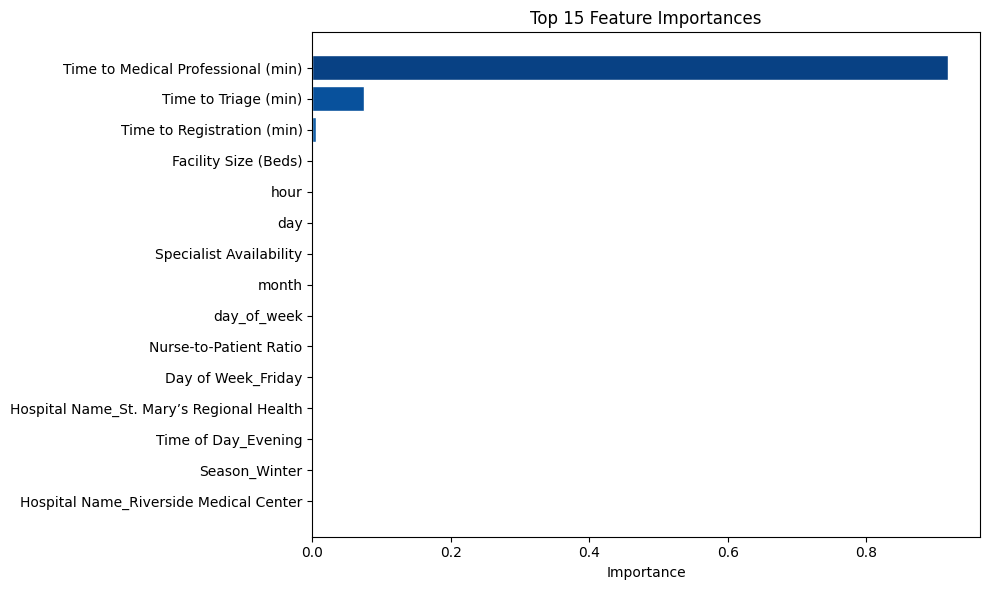

Top 5 features:
                           feature  importance
Time to Medical Professional (min)    0.918558
              Time to Triage (min)    0.074193
        Time to Registration (min)    0.005531
              Facility Size (Beds)    0.000234
                              hour    0.000224


In [50]:
preprocessor_fitted = rf_model.named_steps["preprocessor"]
regressor_fitted    = rf_model.named_steps["regressor"]

cat_feature_names = list(preprocessor_fitted
                         .named_transformers_["cat"]
                         .get_feature_names_out(categorical_cols))
all_feature_names = list(numerical_cols) + cat_feature_names

fi = pd.DataFrame({
    "feature"   : all_feature_names,
    "importance": regressor_fitted.feature_importances_
}).sort_values("importance", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
colors = sns.color_palette("Blues_r", len(fi))
ax.barh(fi["feature"][::-1], fi["importance"][::-1], color=colors[::-1], edgecolor="white")
ax.set(title="Top 15 Feature Importances", xlabel="Importance")
plt.tight_layout()
plt.show()
print("Top 5 features:")
print(fi.head(5).to_string(index=False))

## GradientBoostingRegressor

In [51]:
gb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.1,
        random_state=42
    ))
])

gb_model.fit(X_train_h, y_train_h)
y_pred = gb_model.predict(X_holdout)

add_result("GradientBoostingRegressor", y_holdout, y_pred)
metrics = eval_regression(y_holdout, y_pred)
print(f"R2:      {metrics['R2']:.4f}")
print(f"MAE:     {metrics['MAE']:.4f}")
print(f"RMSE:    {metrics['RMSE']:.4f}")
print(f"MAPE_%:  {metrics['MAPE_%']:.2f}")

R2:      0.9993
MAE:     0.9747
RMSE:    1.5117
MAPE_%:  1.60


In [52]:
results_df = (pd.DataFrame(results)
              .sort_values('R2', ascending=False)
              .reset_index(drop=True))
results_df

,Model,R2,MAE,RMSE,MAPE_%
0,LinearRegression,1.000000,4.955858e-13,5.576234e-13,1.914569e-12
1,GradientBoostingRegressor,0.999317,9.747384e-01,1.511746e+00,1.599495e+00
2,RandomForestRegressor,0.999286,9.797875e-01,1.545685e+00,2.053105e+00
3,DummyRegressor,-0.070021,5.178328e+01,5.982481e+01,2.029775e+02


### Leakage check

If you see near-perfect performance (e.g., `R2 ≈ 1.0`), it often means **target leakage**. In this dataset, the target `Total Wait Time (min)` can be directly determined from time-to-process features such as:

- `Time to Registration (min)`
- `Time to Triage (min)`
- `Time to Medical Professional (min)`

To validate realism, compare performance **with** and **without** these features.

In [53]:
leak_cols = [
    "Time to Registration (min)",
    "Time to Triage (min)",
    "Time to Medical Professional (min)",
]

X_noleak = X.drop(columns=leak_cols, errors="ignore")

num_cols_nl = X_noleak.select_dtypes(include=["int64", "float64"]).columns
cat_cols_nl = X_noleak.select_dtypes(include=["object"]).columns

preprocessor_nl = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols_nl),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols_nl),
    ]
)

split_idx_nl = int(len(X_noleak) * 0.8)
X_train_nl = X_noleak.iloc[:split_idx_nl].copy()
X_val_nl   = X_noleak.iloc[split_idx_nl:].copy()
y_train_nl = y.iloc[:split_idx_nl].copy()
y_val_nl   = y.iloc[split_idx_nl:].copy()

# Linear Regression no-leak
lr_noleak = Pipeline(steps=[
    ("preprocessor", preprocessor_nl),
    ("regressor", LinearRegression()),
])
lr_noleak.fit(X_train_nl, y_train_nl)
y_pred_lr_nl = lr_noleak.predict(X_val_nl)

# RF no-leak 
rf_noleak = Pipeline(steps=[
    ("preprocessor", preprocessor_nl),
    ("regressor", RandomForestRegressor(n_estimators=200, random_state=42)),
])
rf_noleak.fit(X_train_nl, y_train_nl)
y_pred_rf_nl = rf_noleak.predict(X_val_nl)

# GB no-leak 
gb_noleak = Pipeline(steps=[
    ("preprocessor", preprocessor_nl),
    ("regressor", GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, random_state=42)),
])
gb_noleak.fit(X_train_nl, y_train_nl)
y_pred_gb_nl = gb_noleak.predict(X_val_nl)

print("No-Leak Validation Results")
print("LinearRegression:")
print(eval_regression(y_val_nl, y_pred_lr_nl))
print("RandomForest:")
print(eval_regression(y_val_nl, y_pred_rf_nl))
print("GradientBoosting:")
print(eval_regression(y_val_nl, y_pred_gb_nl))

# Comparison table 
noleak_results = pd.DataFrame([
    {"Model": "LinearRegression",    **eval_regression(y_val_nl, y_pred_lr_nl)},
    {"Model": "RandomForest",        **eval_regression(y_val_nl, y_pred_rf_nl)},
    {"Model": "GradientBoosting",    **eval_regression(y_val_nl, y_pred_gb_nl)},
]).sort_values("R2", ascending=False).reset_index(drop=True)

print("-------------------------------------------------------------------------")
print("No-Leak Model Comparison")
print(noleak_results.to_string(index=False))

best_model_name = noleak_results.iloc[0]["Model"]
best_model = {"LinearRegression": lr_noleak, "RandomForest": rf_noleak, "GradientBoosting": gb_noleak}[best_model_name]
print(f" Best model: {best_model_name} (R2={noleak_results.iloc[0]['R2']:.4f}, MAE={noleak_results.iloc[0]['MAE']:.4f})")


No-Leak Validation Results
LinearRegression:
{'R2': 0.7406207608130876, 'MAE': 22.852120939165875, 'RMSE': 29.454581797706307, 'MAPE_%': 53.95991387883134}
RandomForest:
{'R2': 0.7509427916283763, 'MAE': 20.59042552083333, 'RMSE': 28.862557613045364, 'MAPE_%': 40.59218507801356}
GradientBoosting:
{'R2': 0.7536064539086134, 'MAE': 20.61450999724185, 'RMSE': 28.70780045708505, 'MAPE_%': 38.55231870373618}
-------------------------------------------------------------------------
No-Leak Model Comparison
           Model       R2       MAE      RMSE    MAPE_%
GradientBoosting 0.753606 20.614510 28.707800 38.552319
    RandomForest 0.750943 20.590426 28.862558 40.592185
LinearRegression 0.740621 22.852121 29.454582 53.959914
 Best model: GradientBoosting (R2=0.7536, MAE=20.6145)


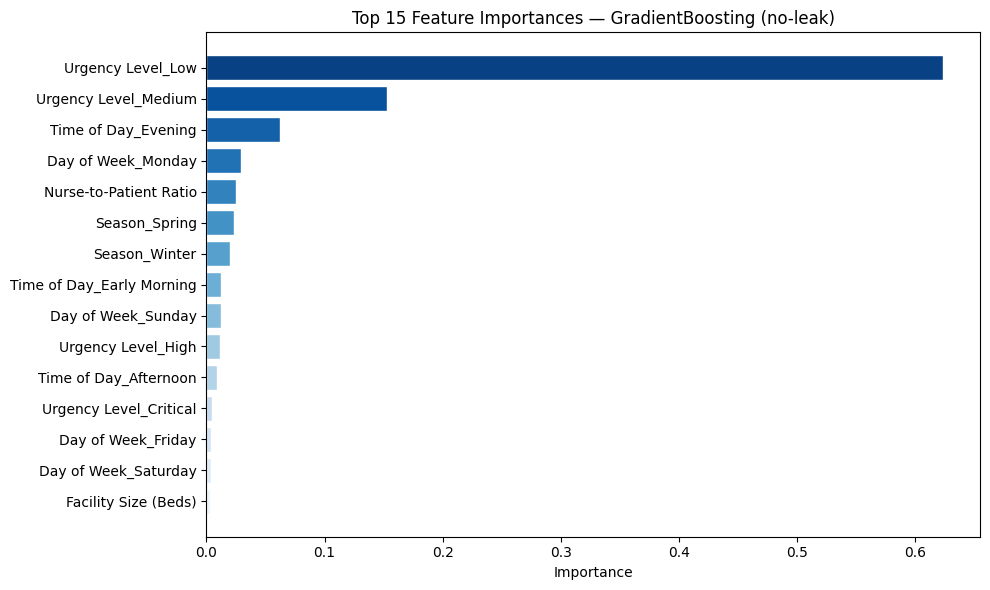

Top 5 features:
               feature  importance
     Urgency Level_Low    0.623723
  Urgency Level_Medium    0.152610
   Time of Day_Evening    0.062200
    Day of Week_Monday    0.029292
Nurse-to-Patient Ratio    0.024859


In [54]:
# Feature importance for the best no-leak model
preprocessor_fitted = best_model.named_steps["preprocessor"]
regressor_fitted    = best_model.named_steps["regressor"]

cat_feature_names_nl = list(preprocessor_fitted
                            .named_transformers_["cat"]
                            .get_feature_names_out(cat_cols_nl))
all_feature_names_nl = list(num_cols_nl) + cat_feature_names_nl

fi = pd.DataFrame({
    "feature"   : all_feature_names_nl,
    "importance": regressor_fitted.feature_importances_
}).sort_values("importance", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
colors = sns.color_palette("Blues_r", len(fi))
ax.barh(fi["feature"][::-1], fi["importance"][::-1], color=colors[::-1], edgecolor="white")
ax.set(title=f"Top 15 Feature Importances — {best_model_name} (no-leak)", xlabel="Importance")
plt.tight_layout()
plt.show()

print("Top 5 features:")
print(fi.head(5).to_string(index=False))

### Conclusion
- **DummyRegressor is the worst model**, used only as a baseline reference.
- Models trained **with** time-to-process features achieve near-perfect R² — this is **data leakage** (those columns are components of the target).
- After removing leaked features, **GradientBoosting and RandomForest** are the real best models, trained on operational features only (Urgency Level, Nurse-to-Patient Ratio, Specialist Availability, Facility Size, temporal features).

## Test Data

In [55]:
y_test = test_data[target]
X_test = test_data.drop(columns=[target])

In [56]:
X_test["Visit Date"] = pd.to_datetime(X_test["Visit Date"])

X_test["hour"]        = X_test["Visit Date"].dt.hour
X_test["day"]         = X_test["Visit Date"].dt.day
X_test["month"]       = X_test["Visit Date"].dt.month
X_test["day_of_week"] = X_test["Visit Date"].dt.dayofweek

X_test.drop(columns=["Visit Date"], inplace=True)
X_test.drop(columns=["Visit ID", "Patient ID", "Hospital ID", "Patient Satisfaction"], inplace=True)

# Drop leaked columns — must match training
X_test.drop(columns=leak_cols, errors="ignore", inplace=True)


In [57]:
# Evaluate best no-leak model on held-out test set
y_pred = best_model.predict(X_test)

metrics = eval_regression(y_test, y_pred)
print(f"Best Model: {best_model_name}")
print(f"R2:      {metrics['R2']:.4f}")
print(f"MAE:     {metrics['MAE']:.4f}")
print(f"RMSE:    {metrics['RMSE']:.4f}")
print(f"MAPE_%:  {metrics['MAPE_%']:.2f}")


Best Model: GradientBoosting
R2:      0.8460
MAE:     19.2724
RMSE:    26.7255
MAPE_%:  31.67


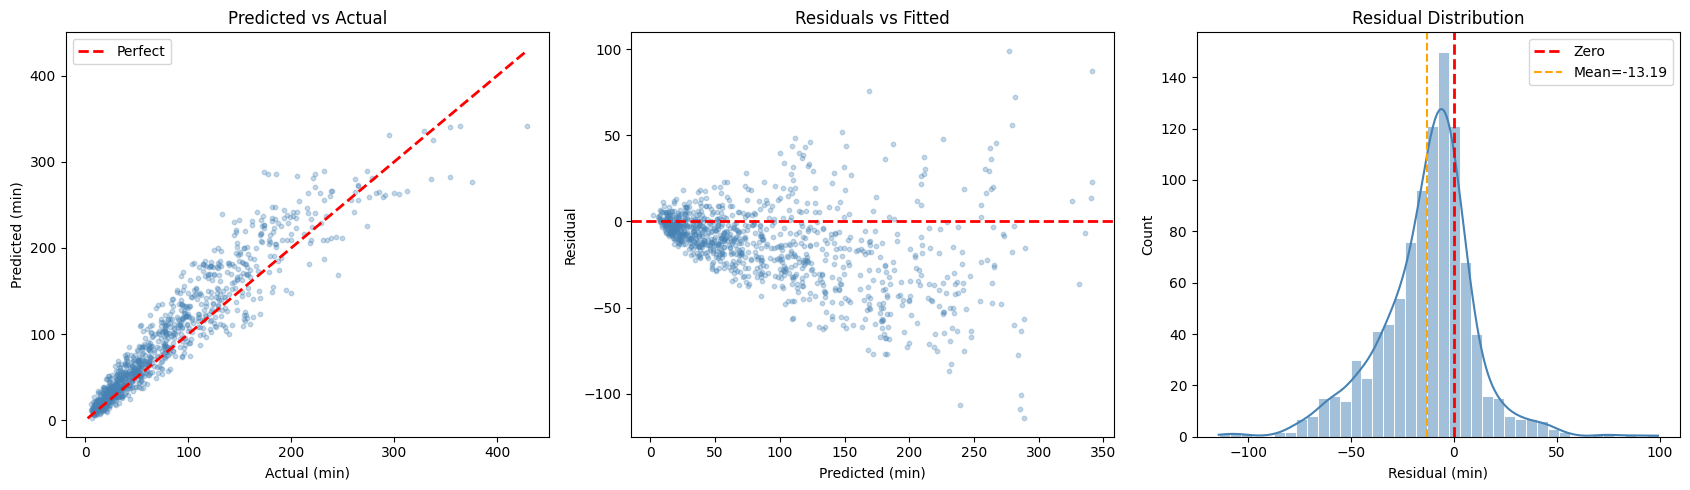

In [58]:
# Residual Analysis
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Predicted vs Actual
axes[0].scatter(y_test, y_pred, alpha=0.3, s=10, color="steelblue")
lim = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(lim, lim, color="red", linewidth=2, linestyle="--", label="Perfect")
axes[0].set(xlabel="Actual (min)", ylabel="Predicted (min)", title="Predicted vs Actual")
axes[0].legend()

# Residuals vs Fitted
axes[1].scatter(y_pred, residuals, alpha=0.3, s=10, color="steelblue")
axes[1].axhline(0, color="red", linewidth=2, linestyle="--")
axes[1].set(xlabel="Predicted (min)", ylabel="Residual", title="Residuals vs Fitted")

# Residual Distribution
sns.histplot(residuals, bins=40, kde=True, ax=axes[2], color="steelblue", edgecolor="white")
axes[2].axvline(0, color="red", linewidth=2, linestyle="--", label="Zero")
axes[2].axvline(residuals.mean(), color="orange", linewidth=1.5, linestyle="--",
                label=f"Mean={residuals.mean():.2f}")
axes[2].set(xlabel="Residual (min)", title="Residual Distribution")
axes[2].legend()

plt.tight_layout()
plt.show()

In [59]:
FEATURE_COLS = [
    "Hospital Name",
    "Region",
    "Day of Week",
    "Season",
    "Time of Day",
    "Urgency Level",
    "Nurse-to-Patient Ratio",
    "Specialist Availability",
    "Facility Size (Beds)",
    "hour",
    "day",
    "month",
    "day_of_week",
]


REPO_ROOT = Path.cwd().parent
MODEL_DIR = REPO_ROOT / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

artifact = {
    "model": best_model,
    "model_name": best_model_name,
    "feature_cols": FEATURE_COLS,
}

joblib.dump(artifact, MODEL_DIR / "er_wait_model.pkl")

print("Saved to:", MODEL_DIR / "er_wait_model.pkl")

Saved to: /mnt/c/Users/osama/Downloads/MLProject/models/er_wait_model.pkl
